In [1]:
import os
SPARK_DRIVER_HOST = '100.111.175.49' # Tailscale IP
os.environ['SPARK_DRIVER_HOST'] = SPARK_DRIVER_HOST
print('Driver IP forced to:', SPARK_DRIVER_HOST)


Driver IP forced to: 100.111.175.49


# FHVHV Trip-Time — Model Analysis & Visualization

Standalone analysis notebook for the Part B Spark ML regression results.

**This notebook does not train, retrain, or modify any model.** It only reads the artifacts
that `BigData_FHVHV_Part_B_ML.ipynb` already produced (its saved predictions, its saved
`PipelineModel`, and its run log) and visualizes them.

Run order: `Part A Processing` → `Part B ML` → **this notebook**.

Contract this notebook depends on (taken directly from Part B, not guessed):

| Item | Source in Part B | Value |
|---|---|---|
| Spark master | `SPARK_MASTER` | `spark://spark-master:7077` |
| Silver features (input to Part B) | `PROCESSED_DATA_PATH` | `s3a://silver/fhvhv/2025/processed_trip_time_features` |
| Best-model predictions | `PREDICTIONS_BASE_PATH/{best_model_name}` | `s3a://gold/fhvhv/2025/trip_time_predictions/{best_model_name}` |
| Best-model inference pipeline | `MODEL_BASE_PATH/{best_model_name}` | `s3a://gold/fhvhv/2025/trip_time_models/{best_model_name}` |
| Run log (all 3 models' metrics) | `LOG_DIR` | `/workspace/logs/fhvhv_part_b_ml.log` |

Part B only ever fits, evaluates, and keeps **in memory** the metrics for all three models
(`LinearRegression`, `RandomForestRegressor`, `GBTRegressor`); it never writes that comparison
table to disk. It only persists the Parquet predictions and the full inference `PipelineModel`
for whichever model turned out best. To compare all three models without retraining anything,
this notebook recovers the other two models' metrics from the Part B run log, and uses the
saved Parquet/PipelineModel artifacts for everything that needs the best model specifically
(Actual vs. Predicted, residuals, feature importance).


## 1. Configuration

In [2]:
# Configuration — must mirror the Part B contract exactly; do not invent new paths here.
# Everything below is copied verbatim from BigData_FHVHV_Part_B_ML.ipynb (cell 1) so that this
# notebook reads exactly what Part B wrote, nothing more and nothing less.
SPARK_MASTER = 'spark://spark-master:7077'
PROCESSED_DATA_PATH = 's3a://silver/fhvhv/2025/processed_trip_time_features'   # Part B's ML input (Part A's Silver output)
PREDICTIONS_BASE_PATH = 's3a://gold/fhvhv/2025/trip_time_predictions'          # Part B writes only the BEST model here
MODEL_BASE_PATH = 's3a://gold/fhvhv/2025/trip_time_models'                    # Part B writes only the BEST model's PipelineModel here
LOG_DIR = '/workspace/logs'                                                    # local (driver) log directory, shared with Part B
ML_LOG_FILENAME = 'fhvhv_part_b_ml.log'                                        # exact filename Part B's logger writes to
LABEL_COL = 'trip_time'
CATEGORICAL_COLS = ['hvfhs_license_num', 'PULocationID', 'DOLocationID', 'shared_request_flag',
                     'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']
NUMERIC_COLS = ['trip_miles', 'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'is_weekend']

# Part B only ever trains/saves these three candidate models, in this order.
CANDIDATE_MODEL_NAMES = ['LinearRegression', 'RandomForestRegressor', 'GBTRegressor']

# --- This notebook's own configuration -----------------------------------------------------
TEST_MODE = True          # informational only here — this notebook never retrains, so it does not
                           # change what data exists; it only affects log messages / expectations below.
VIZ_SAMPLE_FRACTION = 0.5 # fraction applied BEFORE .limit(), so the sample is spread across partitions
VIZ_SAMPLE_SIZE = 10000   # hard cap on rows ever converted to pandas for a single plot
RANDOM_SEED = 42
TOP_N_FEATURES = 20       # feature importance: plot at most this many features

VIZ_LOG_FILENAME = 'fhvhv_viz.log'

# --- Explicit shared-filesystem prerequisite -------------------------------------------------
# PREREQUISITE: This Visualization notebook expects the Part B ML log file to be available at
# f'{LOG_DIR}/{ML_LOG_FILENAME}' on the SAME local/shared filesystem or mount used by Part B
# (e.g. a shared driver volume or shared workspace mount). Part B must be executed first, on
# that same shared mount, so this notebook can read its run log. If that mount is not available
# here, per-model metrics/log-derived sections below cannot work correctly (see Section 5).
print(f'TEST_MODE={TEST_MODE}; master={SPARK_MASTER}')
print(f'Silver input (for target distribution)........ {PROCESSED_DATA_PATH}')
print(f'Predictions base (best model only, per Part B). {PREDICTIONS_BASE_PATH}')
print(f'Model base (best model only, per Part B)....... {MODEL_BASE_PATH}')
print(f'Part B run log.................................. {LOG_DIR}/{ML_LOG_FILENAME}')
print('PREREQUISITE: the Part B ML log file above must exist on the same shared filesystem/mount')
print('              used by Part B (Part B must be run first, on that same mount).')
print(f'VIZ_SAMPLE_SIZE={VIZ_SAMPLE_SIZE}; VIZ_SAMPLE_FRACTION={VIZ_SAMPLE_FRACTION}')


TEST_MODE=True; master=spark://spark-master:7077
Silver input (for target distribution)........ s3a://silver/fhvhv/2025/processed_trip_time_features
Predictions base (best model only, per Part B). s3a://gold/fhvhv/2025/trip_time_predictions
Model base (best model only, per Part B)....... s3a://gold/fhvhv/2025/trip_time_models
Part B run log.................................. /workspace/logs/fhvhv_part_b_ml.log
PREREQUISITE: the Part B ML log file above must exist on the same shared filesystem/mount
              used by Part B (Part B must be run first, on that same mount).
VIZ_SAMPLE_SIZE=10000; VIZ_SAMPLE_FRACTION=0.5


## 2. Logging

Same persistent console + file logging style as Part A / Part B, under its own logger name and log file so it never overwrites the ML run log we are about to read.

In [3]:
# Persistent console + file logging; no credentials are placed in this notebook or log.
import logging, os, sys, time, platform
from pathlib import Path

Path(LOG_DIR).mkdir(parents=True, exist_ok=True)
LOG_PATH = os.path.join(LOG_DIR, VIZ_LOG_FILENAME)
ML_LOG_PATH = os.path.join(LOG_DIR, ML_LOG_FILENAME)

logger = logging.getLogger('fhvhv.viz')
logger.setLevel(logging.INFO)
logger.handlers.clear()
formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
for handler in (logging.FileHandler(LOG_PATH, encoding='utf-8'), logging.StreamHandler(sys.stdout)):
    handler.setFormatter(formatter)
    logger.addHandler(handler)

benchmarks, stage_started = {}, {}
pipeline_started = time.perf_counter()

def start_stage(name):
    stage_started[name] = time.perf_counter()
    logger.info('[VIZ] %s started', name)

def end_stage(name):
    elapsed = time.perf_counter() - stage_started[name]
    benchmarks[name] = elapsed
    logger.info('[VIZ] %s completed in %.2f sec', name, elapsed)
    return elapsed

logger.info('[SYSTEM] Python=%s platform=%s TEST_MODE=%s', platform.python_version(), platform.platform(), TEST_MODE)
logger.info('[SYSTEM] Persistent log=%s', LOG_PATH)
logger.info('[SYSTEM] Reading Part B run log from=%s', ML_LOG_PATH)


2026-08-29 20:13:17,589 | INFO | [SYSTEM] Python=3.10.11 platform=Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.35 TEST_MODE=True
2026-08-29 20:13:17,591 | INFO | [SYSTEM] Persistent log=/workspace/logs/fhvhv_viz.log
2026-08-29 20:13:17,592 | INFO | [SYSTEM] Reading Part B run log from=/workspace/logs/fhvhv_part_b_ml.log


## 3. Spark Initialization

Connects to the **existing** Spark Standalone cluster — the same one Part A/B use. No `local[*]`, no new credentials, no ML imports for training (only `PipelineModel` to *load* the saved model).

In [4]:
start_stage('Spark initialization')
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.ml import PipelineModel   # load-only; never Pipeline/estimators — this notebook does not fit anything

spark = (
    SparkSession.builder
    .appName('FHVHV-ML-Visualization')
    .master(SPARK_MASTER)
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.dynamicAllocation.enabled', 'false')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
sc = spark.sparkContext

# --- Validate we are actually on the cluster, not a local fallback -------------------------
if sc.master.startswith('local'):
    raise RuntimeError(f'[CLUSTER] Local Spark fallback is forbidden; actual master={sc.master}')

# --- Validate S3A/MinIO is configured, without ever placing credentials in this notebook ---
if not sc._jsc.hadoopConfiguration().get('fs.s3a.impl'):
    raise RuntimeError('[DATA_ACCESS] S3A is not configured. Configure the Spark/Kubernetes '
                        'environment; do not add credentials to this notebook.')

logger.info('[CLUSTER] application=%s Spark=%s master=%s defaultParallelism=%s',
            sc.applicationId, spark.version, sc.master, sc.defaultParallelism)
print(f'Connected to cluster: master={sc.master}  application={sc.applicationId}  '
      f'defaultParallelism={sc.defaultParallelism}')
end_stage('Spark initialization')


2026-08-29 20:13:24,790 | INFO | [VIZ] Spark initialization started


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/08/29 20:13:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-08-29 20:13:27,492 | INFO | [CLUSTER] application=app-20260829201327-0084 Spark=3.3.0 master=spark://spark-master:7077 defaultParallelism=2
Connected to cluster: master=spark://spark-master:7077  application=app-20260829201327-0084  defaultParallelism=2
2026-08-29 20:13:27,494 | INFO | [VIZ] Spark initialization completed in 2.70 sec


2.704518005004502

## 4. ML Output / Data Loading

Part B only ever writes the Parquet predictions and the `PipelineModel` for **one** model — whichever
one it decided was best (lowest RMSE). We don't assume which one; we probe the cluster's storage
for which of the three candidate directories actually exists, using a cheap `FileSystem.exists()`
check (no data is read for this).

In [5]:
start_stage('Locate best-model artifacts')

from datetime import datetime

def path_exists(spark_session, path):
    # Cheap existence check on S3A (or any Hadoop FS) -- reads no data.
    jvm = spark_session._jvm
    hadoop_conf = spark_session._jsc.hadoopConfiguration()
    uri = jvm.java.net.URI(path)
    fs = jvm.org.apache.hadoop.fs.FileSystem.get(uri, hadoop_conf)
    return fs.exists(jvm.org.apache.hadoop.fs.Path(path))

def get_last_modified_ms(spark_session, path):
    # Best-effort modification time via the SAME Hadoop/S3A FileSystem handle used for the
    # existence check above -- reads only file/dir metadata, never any row data.
    jvm = spark_session._jvm
    hadoop_conf = spark_session._jsc.hadoopConfiguration()
    uri = jvm.java.net.URI(path)
    fs = jvm.org.apache.hadoop.fs.FileSystem.get(uri, hadoop_conf)
    status = fs.getFileStatus(jvm.org.apache.hadoop.fs.Path(path))
    return status.getModificationTime()  # epoch millis, per Hadoop FileStatus contract

found_predictions, found_models = {}, {}
for candidate in CANDIDATE_MODEL_NAMES:
    pred_path = f'{PREDICTIONS_BASE_PATH}/{candidate}'
    model_path = f'{MODEL_BASE_PATH}/{candidate}'
    found_predictions[candidate] = path_exists(spark, pred_path)
    found_models[candidate] = path_exists(spark, model_path)
    logger.info('[DISCOVERY] %s predictions_exist=%s model_exist=%s', candidate,
                found_predictions[candidate], found_models[candidate])

best_candidates = [name for name in CANDIDATE_MODEL_NAMES
                    if found_predictions[name] and found_models[name]]

if not best_candidates:
    raise FileNotFoundError(
        '[DISCOVERY] No saved predictions + PipelineModel pair was found under '
        f'{PREDICTIONS_BASE_PATH} / {MODEL_BASE_PATH}. Run Part B first.'
    )

if len(best_candidates) == 1:
    # Exactly one candidate -- no ambiguity, use it directly. Directory listing/CANDIDATE_MODEL_NAMES
    # order plays no role in this decision.
    best_model_name = best_candidates[0]
    logger.info('[DISCOVERY] Single model artifact set found: %s. Using it directly.', best_model_name)
    print(f'Single model artifact set found on cluster storage: {best_model_name}')
else:
    # Multiple candidates -- NEVER assume directory listing / CANDIDATE_MODEL_NAMES order reflects
    # recency. Determine each candidate's modification time via the Hadoop/S3A FileSystem handle
    # and select the most recently modified one.
    print(f'Multiple model artifact sets detected: {best_candidates}')
    logger.warning('[DISCOVERY] More than one model artifact set was found (%s). Selecting by '
                    'modification time rather than assuming discovery order reflects recency.',
                    best_candidates)

    candidate_mtimes_ms = {}
    for name in best_candidates:
        pred_path = f'{PREDICTIONS_BASE_PATH}/{name}'
        model_path = f'{MODEL_BASE_PATH}/{name}'
        try:
            pred_mtime = get_last_modified_ms(spark, pred_path)
            model_mtime = get_last_modified_ms(spark, model_path)
        except Exception as exc:
            raise RuntimeError(
                f'[DISCOVERY] Multiple model artifacts were found ({best_candidates}) but the '
                f'modification time for candidate "{name}" could not be safely obtained from the '
                f'configured Hadoop/S3A filesystem ({exc!r}). Refusing to silently fall back to '
                'first-match selection -- fix filesystem access (or remove the stale artifact) '
                'and re-run.'
            ) from exc
        # A candidate's artifact set is only as "fresh" as its most recently written piece.
        candidate_mtimes_ms[name] = max(pred_mtime, model_mtime)

    print('Discovered candidates and their modification times:')
    for name in best_candidates:
        mtime_dt = datetime.fromtimestamp(candidate_mtimes_ms[name] / 1000.0)
        print(f'  - {name}: last modified {mtime_dt.isoformat(sep=" ", timespec="seconds")}')
        logger.info('[DISCOVERY] candidate=%s modified_ms=%s modified=%s', name,
                    candidate_mtimes_ms[name], mtime_dt.isoformat())

    best_model_name = max(candidate_mtimes_ms, key=candidate_mtimes_ms.get)
    selection_reason = (f'most recently modified ({datetime.fromtimestamp(candidate_mtimes_ms[best_model_name] / 1000.0).isoformat(sep=" ", timespec="seconds")}) '
                         f'among {len(best_candidates)} candidates: {best_candidates}')
    print(f'Multiple model artifacts detected. Selecting the most recently modified artifact: {best_model_name}')
    print(f'  Selected because: {selection_reason}')
    logger.warning('[DISCOVERY] Selected %s as most recently modified artifact. Reason: %s',
                    best_model_name, selection_reason)

best_predictions_path = f'{PREDICTIONS_BASE_PATH}/{best_model_name}'
best_model_path = f'{MODEL_BASE_PATH}/{best_model_name}'

logger.info('[DISCOVERY] Best model artifacts resolved to: %s', best_model_name)
print(f'Best-model artifacts resolved to: {best_model_name}')
print(f'  predictions: {best_predictions_path}')
print(f'  model:       {best_model_path}')

# --- Load the artifacts (lazy where possible; only small aggregate actions run here) --------
best_predictions_df = spark.read.parquet(best_predictions_path)   # columns: [LABEL_COL, 'prediction']
# --- HACK: Bypass PythonRDD for PipelineModel.load to avoid Python version mismatch ---
original_text_file = sc.textFile
def mock_text_file(path, minPartitions=None, use_unicode=True):
    df = spark.read.text(path)
    class MockRDD:
        def first(self):
            row = df.first()
            return row[0] if row else ""
    return MockRDD()
sc.textFile = mock_text_file
try:
    best_pipeline_model = PipelineModel.load(best_model_path)
finally:
    sc.textFile = original_text_file

# processed_df is Part A's Silver output / Part B's ML input — used only for the target-distribution
# section below via aggregation + a small controlled sample, never a full collect/toPandas.
processed_df = spark.read.parquet(PROCESSED_DATA_PATH)

predictions_row_count = best_predictions_df.count()  # a count() is a scalar aggregate, not a collect
logger.info('[DATA_LOADING] best_predictions rows=%s columns=%s', predictions_row_count, best_predictions_df.columns)
print(f'Loaded predictions for {best_model_name}: {predictions_row_count:,} rows, columns={best_predictions_df.columns}')
end_stage('Locate best-model artifacts')


2026-08-29 20:13:32,585 | INFO | [VIZ] Locate best-model artifacts started
26/08/29 20:13:32 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
2026-08-29 20:13:33,416 | INFO | [DISCOVERY] LinearRegression predictions_exist=False model_exist=False
2026-08-29 20:13:33,448 | INFO | [DISCOVERY] RandomForestRegressor predictions_exist=True model_exist=True
2026-08-29 20:13:33,476 | INFO | [DISCOVERY] GBTRegressor predictions_exist=False model_exist=False
2026-08-29 20:13:33,478 | INFO | [DISCOVERY] Single model artifact set found: RandomForestRegressor. Using it directly.
Single model artifact set found on cluster storage: RandomForestRegressor
2026-08-29 20:13:33,480 | INFO | [DISCOVERY] Best model artifacts resolved to: RandomForestRegressor
Best-model artifacts resolved to: RandomForestRegressor
  predictions: s3a://gold/fhvhv/2025/trip_time_predictions/RandomForestRegressor
  model:       s3a://gold/fhvhv/2025/tr

26/08/29 20:13:49 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/08/29 20:14:04 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/08/29 20:14:19 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/08/29 20:14:34 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


2026-08-29 20:24:08,637 | INFO | [DATA_LOADING] best_predictions rows=402 columns=['trip_time', 'prediction']
Loaded predictions for RandomForestRegressor: 402 rows, columns=['trip_time', 'prediction']
2026-08-29 20:24:08,644 | INFO | [VIZ] Locate best-model artifacts completed in 636.09 sec


636.091517259003

## 5. Evaluation Results Loading

Part B computes RMSE/MAE/R² and timings for **all three** models, but only ever prints/logs that
comparison — it never writes it to Parquet or any other file. To compare all three models here
without retraining anything, we parse the exact log lines Part B's logger already wrote:

```
[EVALUATION] <model> RMSE=<v> MAE=<v> R2=<v> train=<v>s predict=<v>s evaluate=<v>s
[SUMMARY] Best model by lowest RMSE=<model>; RMSE=<v> MAE=<v> R2=<v>
```

If the log file is missing or a model's line can't be found (e.g. the log was rotated/cleared),
we degrade gracefully: we keep whatever rows we *can* recover and clearly flag the rest as
unavailable, rather than guessing numbers or retraining.

In [6]:
import re
import pandas as pd

start_stage('Evaluation results loading')

# A Part B run begins with a startup/system marker such as: "[SYSTEM] ... TEST_MODE=...".
# We use the LAST such marker in the log as the start of the CURRENT run, and only parse
# [EVALUATION] records that occur AFTER it -- this prevents mixing metrics across runs.
RUN_START_RE = re.compile(r'\[SYSTEM\].*TEST_MODE=')
EVAL_LINE_RE = re.compile(
    r'\[EVALUATION\]\s+(?P<model>\S+)\s+RMSE=(?P<rmse>[-\d.]+)\s+MAE=(?P<mae>[-\d.]+)\s+'
    r'R2=(?P<r2>[-\d.]+)\s+train=(?P<train>[-\d.]+)s\s+predict=(?P<predict>[-\d.]+)s\s+'
    r'evaluate=(?P<evaluate>[-\d.]+)s'
)
SUMMARY_LINE_RE = re.compile(
    r'\[SUMMARY\]\s+Best model by lowest RMSE=(?P<model>\S+);\s+RMSE=(?P<rmse>[-\d.]+)\s+'
    r'MAE=(?P<mae>[-\d.]+)\s+R2=(?P<r2>[-\d.]+)'
)

parsed_metrics = {}
summary_best_model = None
used_evaluation_lines = []
run_start_line_no = None
run_start_line_text = None

if os.path.exists(ML_LOG_PATH):
    with open(ML_LOG_PATH, 'r', encoding='utf-8') as fh:
        all_lines = fh.readlines()

    # --- Find the LAST run-start marker -> that is where the CURRENT run begins ---------------
    run_start_indices = [i for i, line in enumerate(all_lines) if RUN_START_RE.search(line)]
    if run_start_indices:
        run_start_idx = run_start_indices[-1]
        run_start_line_no = run_start_idx + 1  # 1-indexed for display
        run_start_line_text = all_lines[run_start_idx].strip()
    else:
        # No [SYSTEM]/TEST_MODE marker at all (e.g. a legacy log). We cannot determine a run
        # boundary; parse the whole file as a single run rather than guessing, and say so clearly.
        run_start_idx = 0
        logger.warning('[EVAL_LOADING] No "[SYSTEM] ... TEST_MODE=..." run-start marker found in '
                        '%s -- cannot determine current-run boundary. Treating the entire log as '
                        'one run; metrics could be mixed if this log spans multiple Part B runs.',
                        ML_LOG_PATH)

    current_run_lines = all_lines[run_start_idx:]

    print('================ PART B RUN BOUNDARY ================')
    if run_start_line_no is not None:
        print(f'Latest run-start marker: line {run_start_line_no}: {run_start_line_text}')
    else:
        print('No run-start marker found -- parsing entire log as a single run (see warning above).')

    # --- Only parse [EVALUATION] records AFTER the current run's start marker -----------------
    for line in current_run_lines:
        eval_match = EVAL_LINE_RE.search(line)
        if eval_match:
            gd = eval_match.groupdict()
            # Within the current run, keep the LAST occurrence per model (defensive; Part B
            # normally logs one evaluation per model per run).
            parsed_metrics[gd['model']] = {
                'Model': gd['model'],
                'RMSE': float(gd['rmse']),
                'MAE': float(gd['mae']),
                'R2': float(gd['r2']),
                'Training Time': float(gd['train']),
                'Prediction Time': float(gd['predict']),
                'Evaluation Time': float(gd['evaluate']),
            }
            used_evaluation_lines.append(line.strip())
        summary_match = SUMMARY_LINE_RE.search(line)
        if summary_match:
            summary_best_model = summary_match.group('model')

    print(f'[EVALUATION] lines used from the current run ({len(used_evaluation_lines)}):')
    for line in used_evaluation_lines:
        print(f'  {line}')

    logger.info('[EVAL_LOADING] Parsed %d model rows from the CURRENT run (log=%s, run_start_line=%s); '
                'current-run summary best model=%s', len(parsed_metrics), ML_LOG_PATH,
                run_start_line_no, summary_best_model)
else:
    print('================ MISSING PART B LOG (HIGH VISIBILITY WARNING) ================')
    print(f'Expected Part B ML log at: {ML_LOG_PATH}')
    print('This file was NOT found. This means either:')
    print('  1. Part B (BigData_FHVHV_Part_B_ML.ipynb) has not been executed yet, or')
    print('  2. This notebook is not running on the same shared filesystem/mount that Part B wrote to.')
    print('Part B must be run first, on that same shared mount, before this notebook can recover')
    print('per-model metrics. Continuing WITHOUT silently fabricating or reusing older results --')
    print('every model below will show as unavailable (NaN) until the log is available.')
    print('================================================================================')
    logger.warning('[EVAL_LOADING] Part B log not found at %s -- per-model metrics for models other '
                    'than the saved best model are unavailable without retraining, and no log-based '
                    'comparison can be trusted until Part B is run on this shared mount.', ML_LOG_PATH)

# Required models from the CURRENT run only -- an older run's metric is never substituted in.
missing_models = [name for name in CANDIDATE_MODEL_NAMES if name not in parsed_metrics]
if missing_models:
    logger.warning('[EVAL_LOADING] The CURRENT Part B run did not produce an [EVALUATION] result for: '
                    '%s. These models will show as unavailable (NaN) in the comparison table -- an '
                    'older run\'s metric is NEVER substituted in.', missing_models)
    print(f'⚠️  Current run did not evaluate: {missing_models}. Marked unavailable (NaN) below -- '
          f'no older-run metric was substituted.')

if summary_best_model and summary_best_model != best_model_name:
    logger.warning('[EVAL_LOADING] Log summary says best model was %s but discovered artifacts point '
                    'to %s — using the artifacts on disk as the source of truth for what is loadable, '
                    'and the log as the source of truth for metric values.', summary_best_model, best_model_name)

metrics_df = pd.DataFrame(
    [parsed_metrics.get(name, {'Model': name, 'RMSE': float('nan'), 'MAE': float('nan'),
                                'R2': float('nan'), 'Training Time': float('nan'),
                                'Prediction Time': float('nan'), 'Evaluation Time': float('nan')})
     for name in CANDIDATE_MODEL_NAMES]
)
metrics_df = metrics_df.set_index('Model').loc[CANDIDATE_MODEL_NAMES].reset_index()
end_stage('Evaluation results loading')
metrics_df


2026-08-29 20:28:32,694 | INFO | [VIZ] Evaluation results loading started
================ PART B RUN BOUNDARY ================
Latest run-start marker: line 241: 2026-08-29 17:18:51,438 | INFO | [SYSTEM] Python=3.10.11 platform=Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.35 TEST_MODE=True
[EVALUATION] lines used from the current run (3):
  2026-08-29 17:30:59,480 | INFO | [EVALUATION] LinearRegression RMSE=420.3759 MAE=325.3211 R2=0.5328 train=301.02s predict=30.31s evaluate=82.53s
  2026-08-29 17:47:23,520 | INFO | [EVALUATION] RandomForestRegressor RMSE=336.7461 MAE=248.0043 R2=0.7002 train=684.29s predict=59.06s evaluate=240.73s
  2026-08-29 19:00:10,472 | INFO | [EVALUATION] GBTRegressor RMSE=349.2164 MAE=251.4279 R2=0.6776 train=4078.30s predict=56.20s evaluate=232.67s
2026-08-29 20:28:32,713 | INFO | [EVAL_LOADING] Parsed 3 model rows from the CURRENT run (log=/workspace/logs/fhvhv_part_b_ml.log, run_start_line=241); current-run summary best model=RandomForestRegr

,Model,RMSE,MAE,R2,Training Time,Prediction Time,Evaluation Time
0,LinearRegression,420.3759,325.3211,0.5328,301.02,30.31,82.53
1,RandomForestRegressor,336.7461,248.0043,0.7002,684.29,59.06,240.73
2,GBTRegressor,349.2164,251.4279,0.6776,4078.30,56.20,232.67


## 6. Model Performance Comparison

Separate professional bar charts for RMSE, MAE, and R² across all three models, followed by the
full Model Performance Summary table (metrics + timings). The best model is identified from the
**actual parsed numbers** above — lowest RMSE among the rows that have data — not assumed.

2026-08-29 20:28:38,720 | INFO | [COMPARISON] Best model by lowest recovered RMSE=RandomForestRegressor


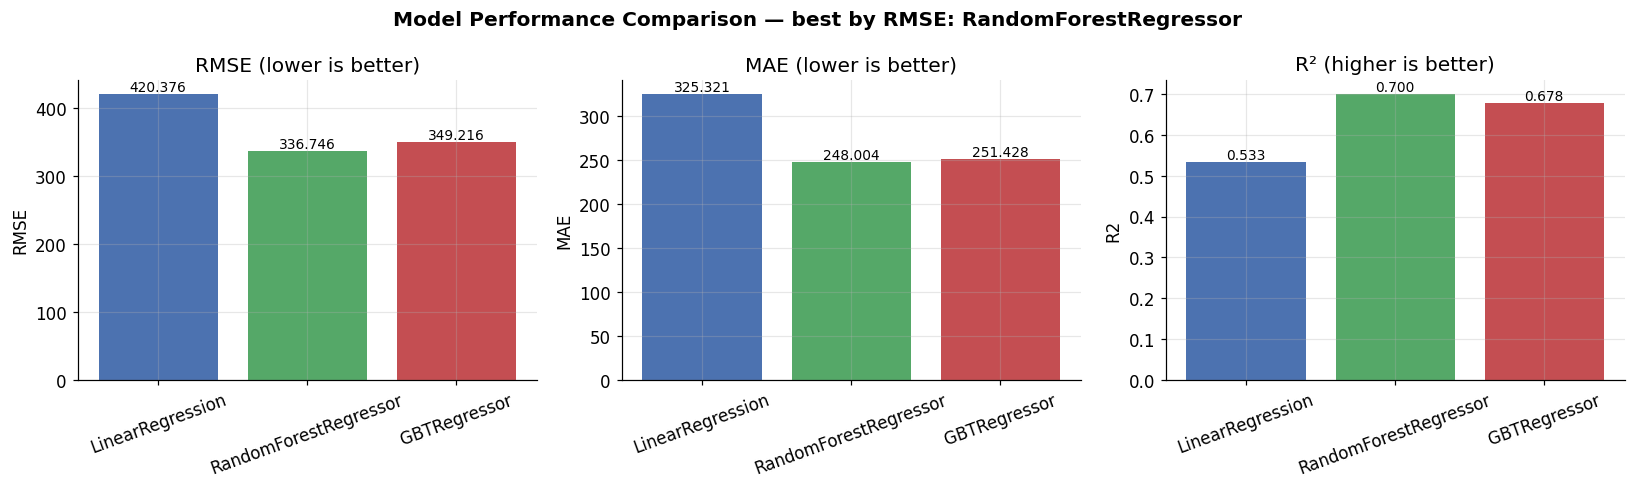

Best model (lowest RMSE among recovered metrics): RandomForestRegressor


In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
MODEL_COLORS = {'LinearRegression': '#4C72B0', 'RandomForestRegressor': '#55A868', 'GBTRegressor': '#C44E52'}
bar_colors = [MODEL_COLORS.get(m, '#888888') for m in metrics_df['Model']]

valid_rmse = metrics_df.dropna(subset=['RMSE'])
if valid_rmse.empty:
    raise RuntimeError('[COMPARISON] No RMSE values could be recovered for any model — cannot '
                        'identify a best model without retraining. Check the Part B log path.')
best_by_metrics_name = valid_rmse.loc[valid_rmse['RMSE'].idxmin(), 'Model']
logger.info('[COMPARISON] Best model by lowest recovered RMSE=%s', best_by_metrics_name)

if best_by_metrics_name != best_model_name:
    logger.warning('[COMPARISON] Best model by RMSE in the log (%s) differs from the model whose '
                    'artifacts were discovered on disk (%s). Using the log-based ranking for the '
                    'charts below, and the on-disk artifacts (%s) for predictions/residuals/'
                    'feature-importance since that is the only model actually saved.',
                    best_by_metrics_name, best_model_name, best_model_name)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(axes, ['RMSE', 'MAE', 'R2'],
                              ['RMSE (lower is better)', 'MAE (lower is better)', 'R\u00b2 (higher is better)']):
    ax.bar(metrics_df['Model'], metrics_df[metric], color=bar_colors)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(metrics_df[metric]):
        if pd.notna(v):
            ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
fig.suptitle(f'Model Performance Comparison — best by RMSE: {best_by_metrics_name}', fontweight='bold')
fig.tight_layout()
plt.show()

print(f'Best model (lowest RMSE among recovered metrics): {best_by_metrics_name}')


### Model Performance Summary Table

In [9]:
summary_table = metrics_df.copy()
summary_table.insert(0, 'Best Model', np.where(summary_table['Model'] == best_by_metrics_name, '\u2605', ''))
styled_summary = (
    summary_table.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}', 'Training Time': '{:.2f}s',
             'Prediction Time': '{:.2f}s', 'Evaluation Time': '{:.2f}s'}, na_rep='N/A')
    .set_caption('Model Performance Summary (metrics + timings recovered from the Part B run log)')
    .hide(axis='index')
)
styled_summary


Best Model,Model,RMSE,MAE,R2,Training Time,Prediction Time,Evaluation Time
,LinearRegression,420.3759,325.3211,0.5328,301.02s,30.31s,82.53s
★,RandomForestRegressor,336.7461,248.0043,0.7002,684.29s,59.06s,240.73s
,GBTRegressor,349.2164,251.4279,0.6776,4078.30s,56.20s,232.67s


## 7. Target Distribution

Analysis of the `trip_time` label from Part B's ML input (Part A's Silver output). Summary
statistics use **Spark aggregations only** (`count`, `mean`, `stddev`, `approxQuantile`) over the
full dataset — small scalars are safe to bring to the driver. Only the histogram/boxplot use a
controlled sample, and that sample is used **only for plotting**; it does not affect any model.

2026-08-29 20:28:43,625 | INFO | [VIZ] Target distribution started


trip_time — full-dataset statistics (via Spark aggregation, no row collection):
  n=100,000  mean=1119.7s  stddev=695.8s  min=1.0s  max=12849.0s
  p25=601.0s  p50=950.0s  p75=1456.0s  p90=2013.0s  p99=12849.0s
2026-08-29 20:29:42,546 | INFO | [TARGET_DIST] n=100000 mean=1119.67 stddev=695.78 p50=950.00 p99=12849.00


2026-08-29 20:29:49,923 | INFO | [TARGET_DIST] Visualization sample size=10000 (VIZ_SAMPLE_SIZE cap=10000)


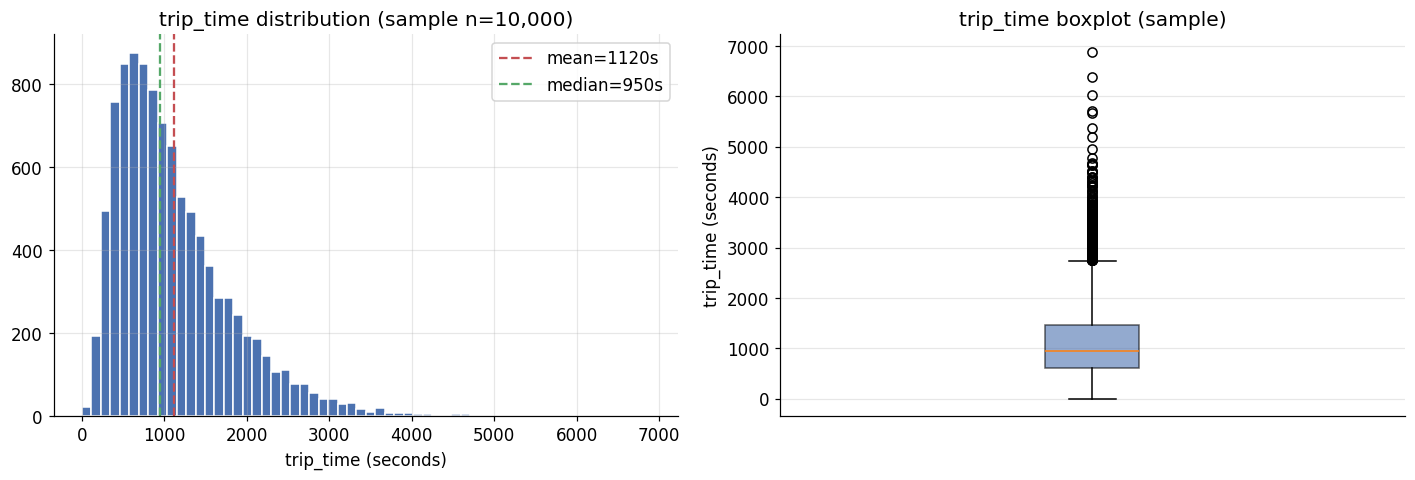

2026-08-29 20:29:50,119 | INFO | [VIZ] Target distribution completed in 66.50 sec


66.4956826350026

In [8]:
start_stage('Target distribution')

# --- Full-dataset aggregation (safe: returns a handful of scalars, not rows) ----------------
agg_row = processed_df.select(
    F.count(LABEL_COL).alias('n'),
    F.mean(LABEL_COL).alias('mean'),
    F.stddev(LABEL_COL).alias('stddev'),
    F.min(LABEL_COL).alias('min'),
    F.max(LABEL_COL).alias('max'),
).first()
quantiles = processed_df.approxQuantile(LABEL_COL, [0.25, 0.5, 0.75, 0.9, 0.99], 0.01)

print('trip_time — full-dataset statistics (via Spark aggregation, no row collection):')
print(f"  n={agg_row['n']:,}  mean={agg_row['mean']:.1f}s  stddev={agg_row['stddev']:.1f}s  "
      f"min={agg_row['min']:.1f}s  max={agg_row['max']:.1f}s")
print(f'  p25={quantiles[0]:.1f}s  p50={quantiles[1]:.1f}s  p75={quantiles[2]:.1f}s  '
      f'p90={quantiles[3]:.1f}s  p99={quantiles[4]:.1f}s')
logger.info('[TARGET_DIST] n=%s mean=%.2f stddev=%.2f p50=%.2f p99=%.2f',
            agg_row['n'], agg_row['mean'], agg_row['stddev'], quantiles[1], quantiles[4])

# --- Controlled sample for the histogram/boxplot only (never the full dataset) --------------
target_sample_pd = (
    processed_df
    .select(LABEL_COL)
    .sample(withReplacement=False, fraction=VIZ_SAMPLE_FRACTION, seed=RANDOM_SEED)
    .limit(VIZ_SAMPLE_SIZE)
    .toPandas()  # small, bounded sample only — the full processed_df is never collected
)
logger.info('[TARGET_DIST] Visualization sample size=%d (VIZ_SAMPLE_SIZE cap=%d)',
            len(target_sample_pd), VIZ_SAMPLE_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(target_sample_pd[LABEL_COL], bins=60, color='#4C72B0', edgecolor='white')
axes[0].axvline(agg_row['mean'], color='#C44E52', linestyle='--', label=f"mean={agg_row['mean']:.0f}s")
axes[0].axvline(quantiles[1], color='#55A868', linestyle='--', label=f'median={quantiles[1]:.0f}s')
axes[0].set_title(f'trip_time distribution (sample n={len(target_sample_pd):,})')
axes[0].set_xlabel('trip_time (seconds)')
axes[0].legend()

axes[1].boxplot(target_sample_pd[LABEL_COL], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[1].set_title('trip_time boxplot (sample)')
axes[1].set_ylabel('trip_time (seconds)')
axes[1].set_xticks([])
fig.tight_layout()
plt.show()
end_stage('Target distribution')


## 8. Actual vs. Predicted (Best Model)

Uses the Parquet predictions Part B already saved for the best model (resolved in Section 4 as
`best_model_name`) — no re-inference, no retraining. A controlled sample (`VIZ_SAMPLE_SIZE=10000`
rows by default) is drawn for the scatter plot; the ideal-fit line is `y = x`.

2026-08-29 20:30:06,102 | INFO | [VIZ] Actual vs predicted started


2026-08-29 20:30:45,457 | INFO | [ACTUAL_VS_PRED] model=RandomForestRegressor sample_rows=188 (sample also reused for residual analysis below)


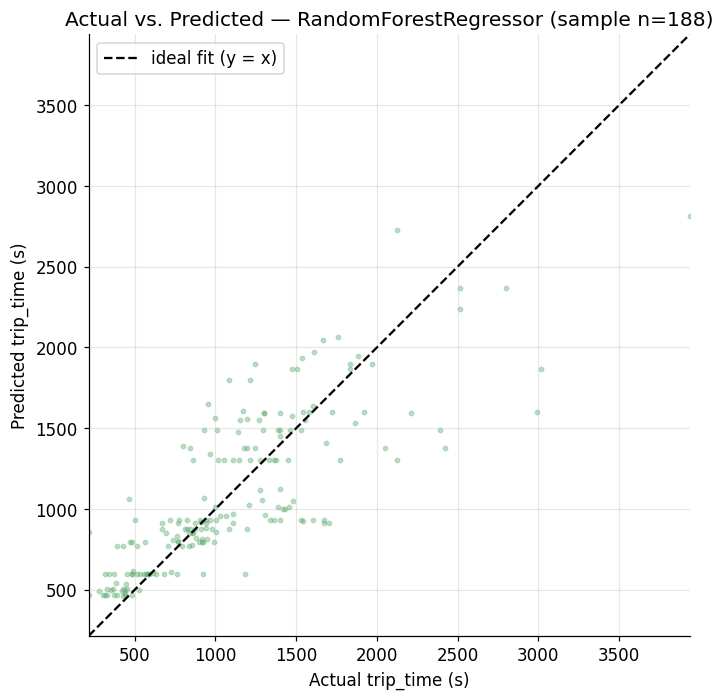

2026-08-29 20:30:45,574 | INFO | [VIZ] Actual vs predicted completed in 39.47 sec


39.473047801002394

In [10]:
start_stage('Actual vs predicted')

# --- Build ONE bounded visualization sample (actual, prediction, residual) here, and reuse it ---
# for Actual-vs-Predicted (this section) AND Residual Distribution / Residuals-vs-Predicted (next
# section), instead of sampling best_predictions_df separately for each chart. This is a single
# Spark action (one .toPandas()) instead of two; the resulting pandas DataFrame is small (capped
# at VIZ_SAMPLE_SIZE rows) and simply held in this Python variable for reuse -- no need to .cache()
# the multi-GB source best_predictions_df to achieve this.
pred_residual_sample_pd = (
    best_predictions_df
    .select(
        LABEL_COL, 'prediction',
        (F.col(LABEL_COL) - F.col('prediction')).alias('residual'),
    )
    .sample(withReplacement=False, fraction=VIZ_SAMPLE_FRACTION, seed=RANDOM_SEED)
    .limit(VIZ_SAMPLE_SIZE)
    .toPandas()  # single controlled sample, reused by this section and the next
)
logger.info('[ACTUAL_VS_PRED] model=%s sample_rows=%d (sample also reused for residual analysis below)',
            best_model_name, len(pred_residual_sample_pd))

# Kept for readability below / in case any downstream cell expects this name.
actual_vs_pred_pd = pred_residual_sample_pd

lims = [
    min(actual_vs_pred_pd[LABEL_COL].min(), actual_vs_pred_pd['prediction'].min()),
    max(actual_vs_pred_pd[LABEL_COL].max(), actual_vs_pred_pd['prediction'].max()),
]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(actual_vs_pred_pd[LABEL_COL], actual_vs_pred_pd['prediction'],
           s=8, alpha=0.35, color=MODEL_COLORS.get(best_model_name, '#4C72B0'))
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.5, label='ideal fit (y = x)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual trip_time (s)')
ax.set_ylabel('Predicted trip_time (s)')
ax.set_title(f'Actual vs. Predicted — {best_model_name} (sample n={len(actual_vs_pred_pd):,})')
ax.legend()
fig.tight_layout()
plt.show()
end_stage('Actual vs predicted')


## 9. Residual Analysis (Best Model)

Residual = Actual − Predicted, computed as a Spark column expression over the **full** predictions
dataset (a distributed operation, not a collect). Only a controlled sample of the resulting
residuals is brought to pandas for plotting.

2026-08-29 20:30:51,495 | INFO | [VIZ] Residual analysis started
2026-08-29 20:30:51,498 | INFO | [RESIDUALS] model=RandomForestRegressor sample_rows=188 (reused from Actual vs Predicted sample above)


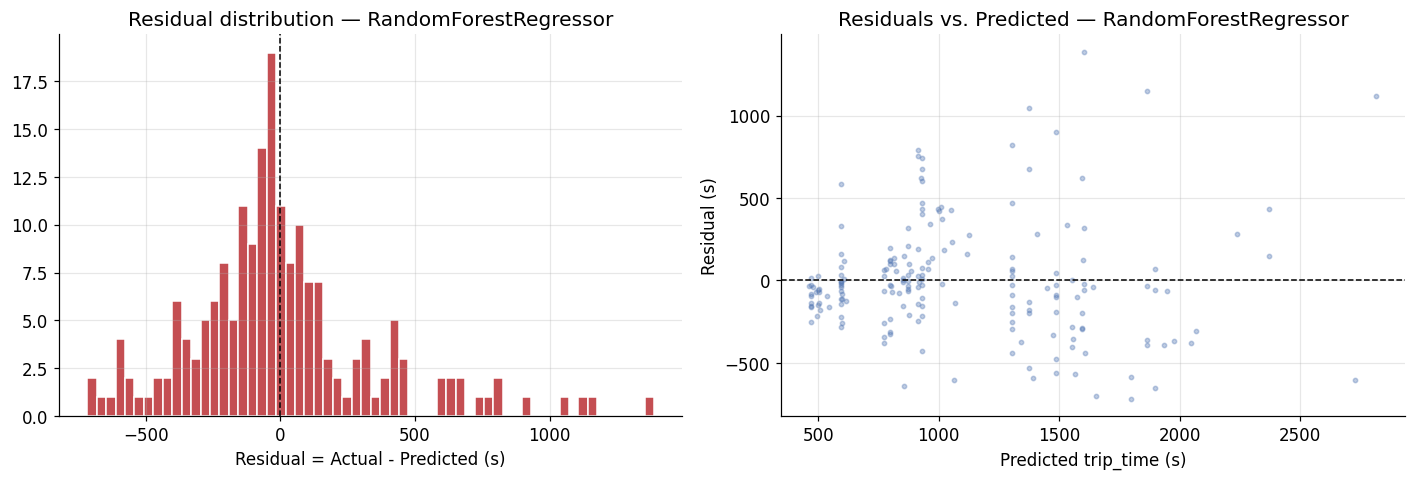

2026-08-29 20:30:51,676 | INFO | [VIZ] Residual analysis completed in 0.18 sec


0.18006093299482018

In [11]:
start_stage('Residual analysis')

# Reuse the SAME bounded sample built in the previous section (actual, prediction, residual) --
# no second sample()/toPandas() pass over best_predictions_df is needed for these two charts.
residual_sample_pd = pred_residual_sample_pd
logger.info('[RESIDUALS] model=%s sample_rows=%d (reused from Actual vs Predicted sample above)',
            best_model_name, len(residual_sample_pd))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(residual_sample_pd['residual'], bins=60, color='#C44E52', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Residual distribution — {best_model_name}')
axes[0].set_xlabel('Residual = Actual - Predicted (s)')

axes[1].scatter(residual_sample_pd['prediction'], residual_sample_pd['residual'],
                 s=8, alpha=0.35, color='#4C72B0')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Residuals vs. Predicted — {best_model_name}')
axes[1].set_xlabel('Predicted trip_time (s)')
axes[1].set_ylabel('Residual (s)')
fig.tight_layout()
plt.show()
end_stage('Residual analysis')


## 10. Feature Importance (Best Model)

Only tree-based models (`RandomForestRegressor`, `GBTRegressor`) expose `featureImportances`; a
`LinearRegression` model does not, and since Part B only ever saves the *best* model, importance
is only available at all when that best model happens to be a tree ensemble. Feature indices are
mapped back to human-readable names using the `ml_attr` metadata that the saved preprocessing
`PipelineModel` attaches to the assembled `features` vector — recovered by transforming a
**5-row** sample (metadata only, not a training run).

2026-08-29 20:30:56,113 | INFO | [VIZ] Feature importance started
2026-08-29 20:30:56,603 | INFO | [FEATURE_IMPORTANCE] model=RandomForestRegressor total_features=478 showing_top=20


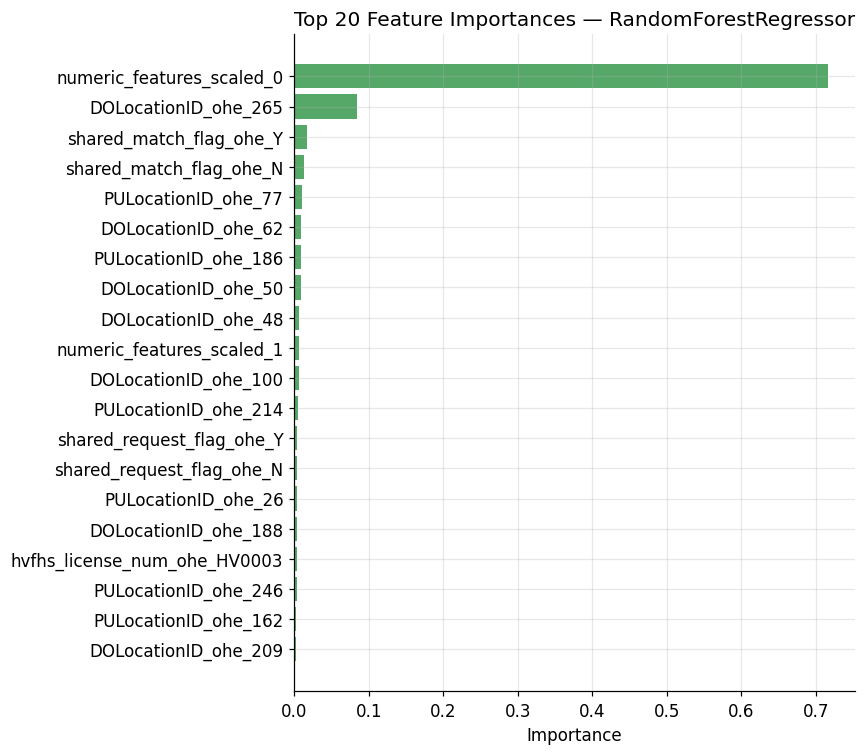

2026-08-29 20:30:56,742 | INFO | [VIZ] Feature importance completed in 0.63 sec


0.6288478619972011

In [12]:
start_stage('Feature importance')

best_estimator_stage = best_pipeline_model.stages[-1]

if not hasattr(best_estimator_stage, 'featureImportances'):
    logger.warning('[FEATURE_IMPORTANCE] %s has no featureImportances attribute — skipping '
                    '(only RandomForestRegressor / GBTRegressor expose this).', best_model_name)
    print(f'⚠️  Feature importance is not available for {best_model_name} '
          f'(it does not expose featureImportances). Skipping this section.')
else:
    importances = best_estimator_stage.featureImportances.toArray()

    # Recover feature names via ml_attr metadata — transforms only 5 rows, purely to read schema
    # metadata, not to score or retrain anything.
    metadata_sample = processed_df.limit(5)
    transformed_sample = best_pipeline_model.transform(metadata_sample)
    ml_attrs = transformed_sample.schema['features'].metadata.get('ml_attr', {}).get('attrs', {})

    feature_names = [f'feature_{i}' for i in range(len(importances))]
    for attr_group in ml_attrs.values():
        for attr in attr_group:
            if attr['idx'] < len(feature_names):
                feature_names[attr['idx']] = attr['name']

    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    top_features = importance_df.head(min(TOP_N_FEATURES, len(importance_df)))
    logger.info('[FEATURE_IMPORTANCE] model=%s total_features=%d showing_top=%d',
                best_model_name, len(importance_df), len(top_features))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(top_features))))
    ax.barh(top_features['feature'][::-1], top_features['importance'][::-1],
            color=MODEL_COLORS.get(best_model_name, '#4C72B0'))
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {len(top_features)} Feature Importances — {best_model_name}')
    fig.tight_layout()
    plt.show()

end_stage('Feature importance')


## 11. Final Model Comparison

In [13]:
best_row = metrics_df.set_index('Model').loc[best_by_metrics_name]

print('================ FINAL MODEL COMPARISON ================')
print(f'Best Model: {best_by_metrics_name}')
print(f"  RMSE: {best_row['RMSE']:.4f}")
print(f"  MAE:  {best_row['MAE']:.4f}")
print(f"  R2:   {best_row['R2']:.4f}")
print()
print(f'Selected because it has the lowest RMSE among the three evaluated models '
      f'(RMSE is the primary metric Part B itself uses to pick a model to save), '
      f'based on the metrics recovered from the Part B run log above — no assumption, '
      f'no retraining.')

if best_by_metrics_name != best_model_name:
    print()
    print(f'⚠️  Note: the artifacts actually saved to disk by Part B belong to "{best_model_name}", '
          f'so Actual-vs-Predicted / Residuals / Feature Importance above are for that model, '
          f'not for "{best_by_metrics_name}". Re-run Part B (without TEST_MODE sampling drift '
          f'between runs) if these should always match.')

logger.info('[FINAL] best_by_metrics=%s best_by_saved_artifacts=%s RMSE=%.4f MAE=%.4f R2=%.4f',
            best_by_metrics_name, best_model_name, best_row['RMSE'], best_row['MAE'], best_row['R2'])


================ FINAL MODEL COMPARISON ================
Best Model: RandomForestRegressor
  RMSE: 336.7461
  MAE:  248.0043
  R2:   0.7002

Selected because it has the lowest RMSE among the three evaluated models (RMSE is the primary metric Part B itself uses to pick a model to save), based on the metrics recovered from the Part B run log above — no assumption, no retraining.
2026-08-29 20:31:02,992 | INFO | [FINAL] best_by_metrics=RandomForestRegressor best_by_saved_artifacts=RandomForestRegressor RMSE=336.7461 MAE=248.0043 R2=0.7002


## 12. Summary

In [14]:
viz_total = time.perf_counter() - pipeline_started
logger.info('[SUMMARY] Visualization total=%.2f sec; best_model=%s; log=%s', viz_total, best_by_metrics_name, LOG_PATH)

print('================ VISUALIZATION BENCHMARK ================')
for stage, elapsed in benchmarks.items():
    print(f'{stage:<36}{elapsed:>10.2f} sec')
print(f'VIZ TOTAL{viz_total:>33.2f} sec')
print()
print(f'Best model:            {best_by_metrics_name}')
print(f'Artifacts analyzed for: {best_model_name}')
print(f'Predictions read from:  {best_predictions_path}')
print(f'Model read from:        {best_model_path}')
print(f'Part B log parsed from: {ML_LOG_PATH}')
print(f'This notebook\'s log:    {LOG_PATH}')
print()
print('No model was trained or retrained in this notebook. No full dataset was collected to the '
      f'driver — every pandas conversion above was capped at VIZ_SAMPLE_SIZE={VIZ_SAMPLE_SIZE:,} rows.')

# NOTE: best_predictions_df and processed_df were never .cache()'d / .persist()'d in this notebook
# (only a single small, bounded pandas sample -- pred_residual_sample_pd, see Section 8/9 -- is
# reused across charts), so there is nothing on these Spark DataFrames to .unpersist(). Calling
# .unpersist() on DataFrames that were never persisted was a no-op that implied caching which
# never happened; it has been removed rather than left as misleading cleanup code.
spark.stop()


2026-08-29 20:31:08,523 | INFO | [SUMMARY] Visualization total=1070.99 sec; best_model=RandomForestRegressor; log=/workspace/logs/fhvhv_viz.log
================ VISUALIZATION BENCHMARK ================
Spark initialization                      2.70 sec
Locate best-model artifacts             636.09 sec
Evaluation results loading                0.02 sec
Target distribution                      66.50 sec
Actual vs predicted                      39.47 sec
Residual analysis                         0.18 sec
Feature importance                        0.63 sec
VIZ TOTAL                          1070.99 sec

Best model:            RandomForestRegressor
Artifacts analyzed for: RandomForestRegressor
Predictions read from:  s3a://gold/fhvhv/2025/trip_time_predictions/RandomForestRegressor
Model read from:        s3a://gold/fhvhv/2025/trip_time_models/RandomForestRegressor
Part B log parsed from: /workspace/logs/fhvhv_part_b_ml.log
This notebook's log:    /workspace/logs/fhvhv_viz.log

No model was